<a href="https://colab.research.google.com/github/Pavithra-5726/Amazon-Review-Analysis-/blob/main/amazon%20sentiment%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install (run once if needed)
!pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from wordcloud import WordCloud

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Amazon_Reviews.csv to Amazon_Reviews.csv


In [5]:
df = pd.read_csv("Amazon_Reviews.csv", engine='python')

In [30]:
df.info()
df.columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 21055 entries, 0 to 21213
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     21055 non-null  object
 1   rating     21055 non-null  int64 
 2   sentiment  21055 non-null  object
 3   cleaned    21055 non-null  object
dtypes: int64(1), object(3)
memory usage: 822.5+ KB


,0
review,0
rating,0
sentiment,0
cleaned,0


In [32]:
df = df[['review','rating']].dropna()
df.rename(columns={'reviewText': 'review', 'overall': 'rating'}, inplace=True)

In [8]:
df['rating'].unique()[:10]

array(['Rated 1 out of 5 stars', 'Rated 5 out of 5 stars',
       'Rated 2 out of 5 stars', 'Rated 4 out of 5 stars',
       'Rated 3 out of 5 stars'], dtype=object)

In [9]:
import re

def extract_rating(text):
    match = re.search(r'\d+', str(text))
    return int(match.group()) if match else None

df['rating'] = df['rating'].apply(extract_rating)

In [10]:
df = df.dropna(subset=['rating'])
df['rating'] = df['rating'].astype(int)

In [11]:
def convert_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(convert_sentiment)

In [12]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,14350
Positive,5820
Neutral,885


In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation/numbers
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned'] = df['review'].apply(clean_text)

df[['review', 'cleaned']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,review,cleaned
0,"I registered on the website, tried to order a ...",registered website tried order laptop entered ...
1,Had multiple orders one turned up and driver h...,multiple order one turned driver phone door nu...
2,I informed these reprobates that I WOULD NOT B...,informed reprobate would going visit sick rela...
3,I have bought from Amazon before and no proble...,bought amazon problem happy service price amaz...
4,If I could give a lower rate I would! I cancel...,could give lower rate would cancelled amazon p...


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned'])
y = df['sentiment']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [17]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9069104725718357
              precision    recall  f1-score   support

    Negative       0.92      0.97      0.95      2921
     Neutral       1.00      0.01      0.01       166
    Positive       0.86      0.88      0.87      1124

    accuracy                           0.91      4211
   macro avg       0.93      0.62      0.61      4211
weighted avg       0.91      0.91      0.89      4211



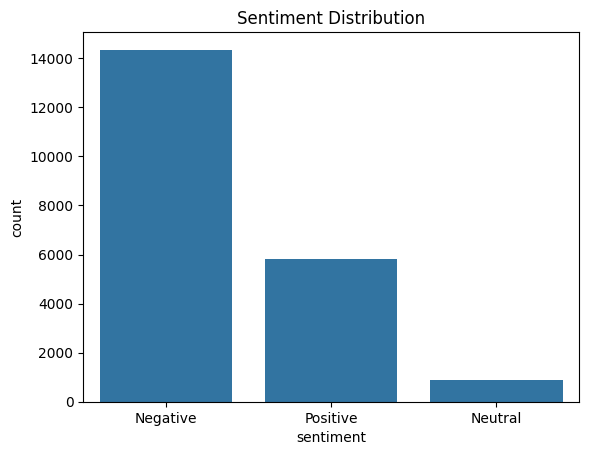

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

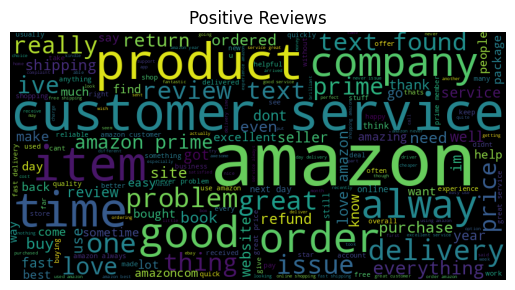

In [19]:
from wordcloud import WordCloud

positive_text = " ".join(df[df['sentiment']=='Positive']['cleaned'])

wc = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wc)
plt.axis('off')
plt.title("Positive Reviews")
plt.show()

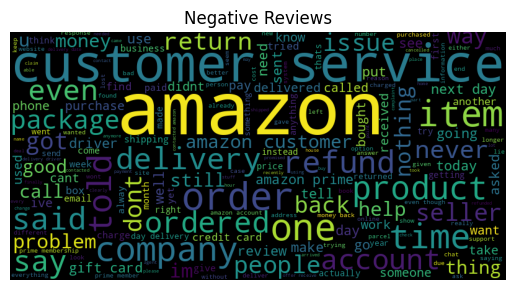

In [20]:
negative_text = " ".join(df[df['sentiment']=='Negative']['cleaned'])

wc = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wc)
plt.axis('off')
plt.title("Negative Reviews")
plt.show()

In [21]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.7 MB/s eta 0:00:00


In [22]:
df.to_csv("final_sentiment.csv", index=False)


In [25]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)
from google.colab import files

files.download("final_sentiment.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>